In [1]:
# https://www.marktechpost.com/2026/04/27/how-to-build-a-lightweight-vision-language-action-inspired-embodied-agent-with-latent-world-modeling-and-model-predictive-control/

In [2]:
import random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Dict, List
from torch.utils.data import Dataset, DataLoader
from torch import device
from einops import reduce
from einops.layers.torch import Rearrange

try:
   from tqdm.auto import tqdm
except Exception:
   def tqdm(x, **kwargs): return x


SEED = 7
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



/home/server/miniconda3/envs/dev_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


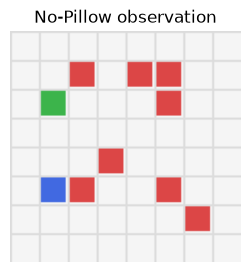

In [3]:
@dataclass
class WorldConfig:
    grid_size: int=8
    cell_px: int=14
    max_steps: int=45
    n_obstacles: int=8
    spawn_margin: int=1

class GridWorld:
    ACTION_NAMES = { 0: "UP", 1: "DOWN", 2: "LEFT", 3:"RIGHT" }
    ACTIONS = { 0: (0, -1), 1: (0, 1), 2: (-1, 0), 3: (1, 0) }

    def __init__(self, cfg: WorldConfig):
        self.cfg = cfg
        self.reset()

    def reset(self) -> Dict:
        g = self.cfg.grid_size
        self.steps = 0

        def sample_empty(exclude=set()):
            while True:
                x = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                y = random.randint(self.cfg.spawn_margin, g-1-self.cfg.spawn_margin)
                if (x,y) not in exclude: 
                    return (x,y)
        self.obstacles = set()
        ax, ay = sample_empty()
        gx, gy = sample_empty(exclude=[(ax, ay)])
        used = {(ax,ay),(gx,gy)}
        for _ in range(self.cfg.n_obstacles):
            ox, oy = sample_empty(exclude=used)
            self.obstacles.add((ox,oy))
            used.add((ox,oy))
        self.agent = (ax,ay)
        self.goal = (gx,gy)
        return {"image": self._render_u8()}

    def _in_bounds(self, x, y):
       return 0 <= x < self.cfg.grid_size and 0 <= y < self.cfg.grid_size


    def _dist_to_goal(self, pos: Tuple[int,int]) -> float:
        x,y = pos; gx,gy = self.goal
        return abs(x-gx)+abs(y-gy)


    def _state_vector(self) -> np.ndarray:
        g = self.cfg.grid_size - 1
        ax, ay = self.agent
        gx, gy = self.goal
        return np.array([ax/g, ay/g, gx/g, gy/g], dtype=np.float32)

    def step(self, action: int):
        self.steps += 1
        dx, dy = self.ACTIONS[int(action)]
        x, y = self.agent
        nx, ny = x+dx, y+dy
        if self._in_bounds(nx, ny) and (nx, ny) not in self.obstacles:
            self.agent = (nx, ny)
        done = (self.agent == self.goal) or (self.steps >= self.cfg.max_steps)
        d_prev = self._dist_to_goal((x,y))
        d_now = self._dist_to_goal(self.agent)
        reward = 0.1*(d_prev - d_now) + (1.0 if self.agent == self.goal else 0.0)
        obs = {"image": self._render_u8()}
        info = {"state": self._state_vector()}
        return obs, float(reward), bool(done), info

    def _render_u8(self) -> np.ndarray:
        g, s = self.cfg.grid_size, self.cfg.cell_px
        H = W = g*s
        bg = np.array([245,245,245], np.uint8)
        gridline = np.array([220,220,220], np.uint8)
        obstacle_c = np.array([220,70,70], np.uint8)
        goal_c = np.array([60,180,75], np.uint8)
        agent_c = np.array([65,105,225], np.uint8)
        img = np.empty((H,W,3), np.uint8); img[...] = bg
        img[::s,:,:] = gridline
        img[:,::s,:] = gridline
        def paint_cell(x,y,color):
            y0,y1 = y*s,(y+1)*s
            x0,x1 = x*s,(x+1)*s
            img[y0+1:y1-1, x0+1:x1-1] = color
        for (ox,oy) in self.obstacles: paint_cell(ox,oy, obstacle_c)
        gx,gy = self.goal; paint_cell(gx,gy, goal_c)
        ax,ay = self.agent; paint_cell(ax,ay, agent_c)
        return img

cfg = WorldConfig()
env = GridWorld(cfg)
plt.figure(figsize=(3,3))
plt.imshow(env.reset()["image"]); plt.axis("off"); plt.title("No-Pillow observation"); plt.show()


def to_tensor_img_u8(img_u8: np.ndarray) -> torch.Tensor:
   return torch.from_numpy(img_u8).permute(2,0,1).float() / 255.0


In [4]:
from typing import Any


class TransitionDataset(Dataset):
    def __init__(self, items) -> None:
        super().__init__()
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, index) -> Any:
        return self.items[index]

def collect_transitions(n_episodes=120):
    items = []
    env = GridWorld(cfg=cfg)
    for _ in tqdm(range(n_episodes), desc="Collect"):
        obs = env.reset()
        img = to_tensor_img_u8(obs["image"])
        for _ in range(cfg.max_steps):
            action = random.randint(0, 3)
            new_obj, reward, done, info = env.step(action=action)
            next_img = to_tensor_img_u8(new_obj["image"])
            next_state = torch.from_numpy(info["state"]).float()
            goal = next_state[2:4].clone()
            items.append({
                "img": img, 
                "action": torch.tensor(action, dtype=torch.long), 
                "next_img": next_img,
                "next_state": next_state, 
                "goal": goal   
            })
            img = next_img
            if done:
                break
    return items

items = collect_transitions(n_episodes=120)
print("Transitions: ", len(items))
H, W = items[0]["img"].shape[1], items[0]["img"].shape[2]
dataloader = DataLoader(TransitionDataset(items), batch_size=64, shuffle=True, num_workers=0, drop_last=True)

Collect:   0%|          | 0/120 [00:00<?, ?it/s]

Collect:  14%|█▍        | 17/120 [00:00<00:00, 154.96it/s]

Collect:  28%|██▊       | 33/120 [00:00<00:00, 116.50it/s]

Collect:  39%|███▉      | 47/120 [00:00<00:00, 122.33it/s]

Collect:  53%|█████▎    | 64/120 [00:00<00:00, 138.33it/s]

Collect:  66%|██████▌   | 79/120 [00:00<00:00, 140.84it/s]

Collect:  79%|███████▉  | 95/120 [00:00<00:00, 144.30it/s]

Collect:  95%|█████████▌| 114/120 [00:00<00:00, 156.70it/s]

Collect: 100%|██████████| 120/120 [00:00<00:00, 143.62it/s]

Transitions:  4587


In [5]:
from typing import Any


class Encoder(nn.Module):
    def __init__(self, H, W, zdim=64) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 24, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(24, 48, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv2d(48, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        with torch.no_grad():
            self.feat_shape = tuple(self.net(torch.zeros(1, 3, H, W)).shape[1:])
        self.flatten = Rearrange('b c h w -> b (c h w)')
        self.fc = nn.Linear(int(np.prod(self.feat_shape)), zdim)
    def forward(self, x):
        return self.fc(self.flatten(self.net(x)))

class Decoder(nn.Module):
    def __init__(self, feat_shape, zdim=64):
        super().__init__()
        C, h, w = feat_shape
        
        self.net = nn.Sequential(
            nn.Linear(zdim, C * h * w),
            Rearrange('b (c h w) -> b c h w', c=C, h=h, w=w),
            
            nn.ConvTranspose2d(C, 48, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(48, 24, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(24, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)
    

class VLASimLite(nn.Module):
    def __init__(self, H, W, zdim=64, act_dim=5, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.enc = Encoder(H, W, zdim)
        self.dec = Decoder(self.enc.feat_shape, zdim)
        self.act_emb = nn.Embedding(act_dim, 16)
        self.goal_net = nn.Sequential(nn.Linear(2,16), nn.ReLU(), nn.Linear(16,16))
        self.dyn = nn.Sequential(
            nn.Linear(zdim+16+16, 128), nn.ReLU(),
            nn.Linear(128, zdim)
        )
        self.state = nn.Sequential(
            nn.Linear(zdim, 64), nn.ReLU(),
            nn.Linear(64, 4),
            nn.Sigmoid()
        )
    def encode(self, img):
        return self.enc(img)

    def predict_next_latent(self, z, a, goal):
        return self.dyn(
            torch.cat([z, self.act_emb(a), self.goal_net(goal)], dim=-1)
        )
    def decode(self, z):
        return self.dec(z)

    def forward(self, img, act, goal):
        z = self.enc(img)
        z_next = self.predict_next_latent(z, act, goal)
        return z_next, self.decode(z_next), self.state(z_next)

In [6]:
model = VLASimLite(H, W, zdim=64, act_dim=5).to(device=device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)


In [7]:
def train(epochs=30):
    model.train()
    for epoch in range(1, epochs+1):
        losses = []
        for batch in dataloader:
            img = batch["img"].to(device)
            action = batch["action"].to(device)
            next_img = batch["next_img"].to(device)
            next_state = batch["next_state"].to(device)
            goal = batch["goal"].to(device)
            z_next, img_pred, st_pred = model(img, action, goal)
            loss = F.l1_loss(img_pred, next_img) + 3.0*F.mse_loss(st_pred, next_state) + 1e-4*z_next.pow(2).mean()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()
            losses.append(loss.item())
        print("Epoch", epoch, "loss", float(np.mean(losses)))
train(epochs=30)

Epoch 1 loss 0.3795683480484385


Epoch 2 loss 0.22231231294047665


Epoch 3 loss 0.12928988154925092


Epoch 4 loss 0.11047867055929883


In [8]:
# Random shooting MPC
@torch.no_grad()
def mpc_action(img, horizon=6, n_candidates=120, action_space=4):
    model.eval()
    # encode the current observation into label
    z = model.encode(img)
    current_state = model.state(z)
    goal = current_state[:,2:4].clamp(0,1)
    # sample random action
    candidates = torch.randint(0, action_space, (n_candidates, horizon), device=device)
    # copy z and goal so all candidates can run in parallel
    z_roll = z.repeat(n_candidates, 1)
    goal_roll = goal.repeat(n_candidates, 1)
    # loop the dynamics
    for t in range(horizon):
        z_roll = model.predict_next_latent(z_roll, candidates[:,t], goal_roll)
    final_state = model.state(z_roll)
    dist = torch.abs(final_state[:,0:2] - final_state[:,2:4]).sum(dim=-1)
    changes = (candidates[:, 1:] != candidates[:, :-1]).float().mean(dim=1)
    score = dist + 0.12*changes
    best = torch.argmin(score)
    return int(candidates[best,0].item())

    

In [9]:
@torch.no_grad()
def predict_next_frame(img_u8, action):
    model.eval()
    img = to_tensor_img_u8(img_u8).unsqueeze(0).to(device)
    z = model.encode(img)
    state = model.state(z)
    goal = state[:, 2:4].clamp(0, 1)
    act = torch.tensor([action], dtype=torch.long, device=device)
    z_next = model.predict_next_latent(z, act, goal)
    pred = model.decode(z_next)[0].cpu().permute(1, 2, 0).numpy()
    return (pred*255.0).clip(0,255).astype(np.uint8)

In [10]:
def run_episode(max_steps=45):
    e = GridWorld(cfg)
    obs = e.reset()
    real, pred, acts, rews = [], [], [], []
    for _ in range(max_steps):
        img = obs["image"]
        real.append(img)
        a = mpc_action(to_tensor_img_u8(img).unsqueeze(0).to(device), horizon=6, n_candidates=120)
        pred.append(predict_next_frame(img, a))
        obs, r, done, info = e.step(a)
        acts.append(a); rews.append(r)
        if done:
            real.append(obs["image"])
            pred.append(pred[-1])
            break
    return real, pred, acts, rews

real, pred, acts, rews = run_episode()
print("Steps:", len(acts), "Return:", round(sum(rews), 3))

Steps: 45 Return: 0.0


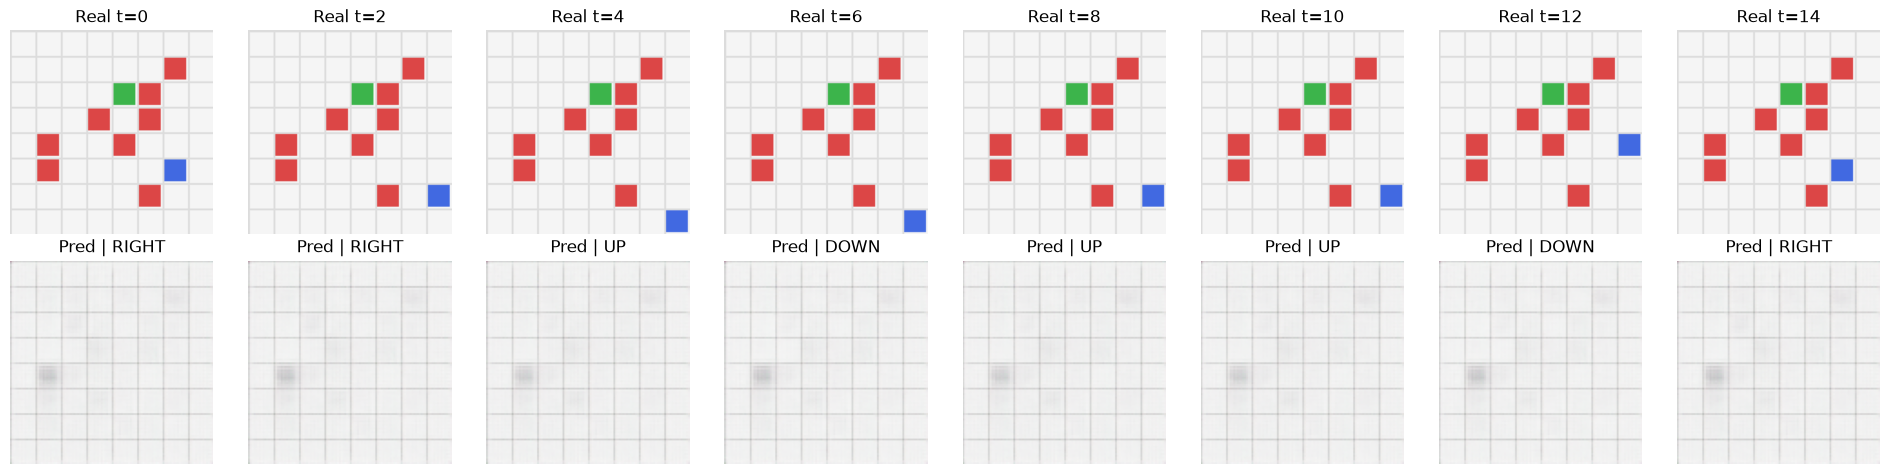

Pipeline OK


In [11]:
def show(real, pred, acts, every=2, panels=8):
    idxs = list(range(0, min(len(acts), every*panels), every))
    n = len(idxs)
    plt.figure(figsize=(2.4*n, 4.8))
    for j,i in enumerate(idxs):
        plt.subplot(2,n,j+1); plt.imshow(real[i]); plt.axis("off"); plt.title(f"Real t={i}")
        plt.subplot(2,n,n+j+1); plt.imshow(pred[i]); plt.axis("off"); plt.title(f"Pred | {GridWorld.ACTION_NAMES[acts[i]]}")
    plt.tight_layout(); plt.show()

show(real, pred, acts, every=2, panels=8)
print("Pipeline OK")

In [ ]:
def evaluate(policy, n_episodes=50, max_steps=45):
    succ, rets, lens = 0, [], []
    for _ in tqdm(range(n_episodes), desc=policy.__name__, leave=False):
        e = GridWorld(cfg); obs = e.reset(); total = 0.0
        for t in range(max_steps):
            obs, r, done, info = e.step(policy(obs["image"]))
            total += r
            if done: break
        succ += int(e.agent == e.goal); rets.append(total); lens.append(t+1)
    return succ/n_episodes, float(np.mean(rets)), float(np.mean(lens))

def random_policy(img_u8): return random.randint(0, 3)
def mpc_policy(img_u8): return mpc_action(to_tensor_img_u8(img_u8).unsqueeze(0).to(device))

for pol in (random_policy, mpc_policy):
    sr, ret, ln = evaluate(pol)
    print(f"{pol.__name__:14s} success={sr:.2%} return={ret:.3f} steps={ln:.1f}")
